In [1]:
!nrnivmodl /home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/mechanism
from neuron import h
from neuron.units import ms, mV
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import plotly
from neuron import clear_gui_callback
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from scipy.integrate import cumtrapz
from numpy.linalg import pinv, eig
import numpy as np
from multiprocessing import Pool
font2={'family':'Times New Roman',
'weight':'bold',
'size': 10}
# 自定义刻度标签显示格式

from matplotlib.ticker import FuncFormatter
def format_func(value, tick_number):
    return f'{value:.0f}'  # 将刻度值格式化为小数点后两位

def plot_curve(ax2,x,y,color='black',title='', linestyle='-',xlim=[0,100],dx=20,ylim=[0,10],dy=5.0, fontsize=10, alpha = 1.0, xlabel='Time/ms', ylabel = 'Frequency/Hz', label='',ynum_decimals =1):
    if color:
        ax2.plot(x,y,color=color,linewidth=2,linestyle=linestyle,alpha=alpha, label=label)
    else:
        ax2.plot(x,y,linewidth=2,alpha=alpha, linestyle=linestyle,label=label)
    ax2.set_xlabel(xlabel,font2)
    ax2.set_ylabel(ylabel,font2)
    
    # def format_funcx(value, tick_number, num_decimals=xnum_decimals):
    #     if num_decimals==0:
    #         return f'{value:.0f}'
    #     return f'{value:.{num_decimals}f}'

    def format_funcy(value, tick_number, num_decimals=ynum_decimals):
        if num_decimals==0:
          return f'{value:.0f}'
        return f'{value:.{num_decimals}f}'

    # if dx:
    #     ax2.set_xticks(np.arange(xlim[0], xlim[1] + dx, dx))
    #     ax2.set_xticklabels(ax2.get_xticks(), fontsize=fontsize, weight='bold')
    #     ax2.set_xlim([xlim[0], xlim[1]])
    #     ax2.xaxis.set_major_formatter(FuncFormatter(format_funcx))

    if dy:
        ax2.set_yticks(np.arange(ylim[0], ylim[1] + dy, dy))
        ax2.set_yticklabels(ax2.get_yticks(), fontsize=fontsize, weight='bold')
        ax2.set_ylim([ylim[0], ylim[1]])
        ax2.yaxis.set_major_formatter(FuncFormatter(format_funcy))
        
  
    if xlim:
       ax2.set_xticks(np.arange(xlim[0],xlim[1]+dx,dx))
       ax2.set_xticklabels(np.arange(xlim[0],xlim[1]+dx,dx),fontsize=10,weight='bold')
       ax2.set_xlim(xlim)
    # if ylim:
    #    ax2.set_yticks(np.arange(ylim[0],ylim[1]+dy,dy))
    #    ax2.set_yticklabels(np.arange(ylim[0],ylim[1]+dy,dy),fontsize=10,weight='bold')
    #    ax2.set_ylim(ylim)
    if title:
       ax2.set_title('{0}'.format(title),fontsize=12,weight='bold')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    if label:
       ax2.legend(loc='best',prop=font2,edgecolor='white')

h.load_file('nrngui.hoc')
h.load_file("import3d.hoc")

morphologyFilename = "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hoc"
biophysicalModelTemplateFilename = "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/PFCtemplate.hoc"

h.load_file(biophysicalModelTemplateFilename)

/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/local_mean_conductance
Mod files: "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/mechanism//home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/mechanism/ampain.mod" "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/mechanism//home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/mechanism/ampa.mod" "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/mechanism//home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/mechanism/ca

--No graphics will be displayed.


1.0

0.0746802999053033


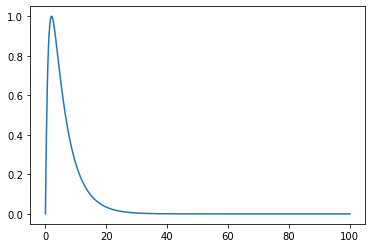

In [2]:
run_dt=0.1
syn_tau1 = 1.
syn_tau2 = 5.
fE = 1e-3
t=np.arange(0,100+run_dt,run_dt)
NE = ((syn_tau1/syn_tau2)**(syn_tau1/(syn_tau2-syn_tau1))-(syn_tau1/syn_tau2)**(syn_tau2/(syn_tau2-syn_tau1)))**-1
uE = NE*(np.exp(-t/syn_tau2)-np.exp(-t/syn_tau1))
plt.plot(t,uE)
ground_truth = np.mean(uE)
print(ground_truth)

In [3]:
neuron = h.FScell(morphologyFilename)

Opening gjhui/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hoc
Denrite No!
1
1
1
0
0
1
1
1
1
1
0
0
0
0
1
1
1
1
1
1
1
1
0
0
0
0
0
1
1
1
0
1
1
1
1
1
1
1
1
0
1
1
1
1
1
1
0
0
0
0
0
0
1
1
1
0
0
0
1
1
1
0
0
1
0
1
1
1


In [5]:
def recovery_of_local_conductance(run_dt,dV, fE, passive = False, 
                    E = True, loc=58, 
                    location ='dend'):
    
    neuron = h.FScell(morphologyFilename)
    
    if passive:
        for sec in h.allsec():
            # 检查 section 是否有主动离子通道
            if h.ismembrane("cal", sec=sec):
                sec.gcalbar_cal = 0.
            if h.ismembrane("calc", sec=sec):
                sec.gcabar_calc = 0.
            if h.ismembrane("calcb", sec=sec):
                sec.gcalbar_calcb = 0.
            if h.ismembrane("can", sec=sec):
                sec.gcabar_can = 0.
            if h.ismembrane("cancr", sec=sec):
                sec.gcabar_cancr = 0.
            if h.ismembrane("canin", sec=sec):
                sec.gcalbar_canin = 0.
            if h.ismembrane("car",sec=sec):
                sec.gcabar_car = 0.
            if h.ismembrane("cat",sec=sec):
                sec.gcatbar_cat = 0.
            if h.ismembrane("catcb",sec=sec):
                sec.gcatbar_catcb = 0.
            if h.ismembrane("h",sec=sec):
                sec.gbar_h = 0.
            if h.ismembrane("hcb",sec=sec):
                sec.gbar_hcb = 0.
            if h.ismembrane("hin",sec=sec):
                sec.gbar_hin = 0.
            if h.ismembrane("ican",sec=sec):
                sec.gbar_ican = 0.
            if h.ismembrane("iCcb",sec=sec):
                sec.gkcbar_iCcb = 0.
            if h.ismembrane("iCcr",sec=sec):
                sec.gkcbar_iCcr = 0.
            if h.ismembrane("iCin",sec=sec):
                sec.gkcbar_iCin = 0.
            if h.ismembrane("IKs",sec=sec):
                sec.gKsbar_IKs = 0.  
            if h.ismembrane("IKscb",sec=sec):
                sec.gKsbar_IKscb = 0.
            if h.ismembrane("IKscr", sec=sec):
                sec.gKsbar_IKscr = 0.
            if h.ismembrane("IKsin", sec=sec):
                sec.gKsbar_IKsin = 0.
            if h.ismembrane("kad", sec=sec):
                sec.gkabar_kad = 0.
            if h.ismembrane("kadcr", sec=sec):
                sec.gkabar_kadcr = 0.
            if h.ismembrane("kadin",sec=sec):
                sec.gkabar_kadin = 0.
            if h.ismembrane("kap",sec=sec):
                sec.gkabar_kap = 0.
            if h.ismembrane("kapcb",sec=sec):
                sec.gkabar_kapcb = 0.
            if h.ismembrane("kapin",sec=sec):
                sec.gkabar_kapin = 0.
            if h.ismembrane("kca",sec=sec):
                sec.gbar_kca = 0.
            if h.ismembrane("kcain",sec=sec):
                sec.gbar_kcain = 0.
            if h.ismembrane("iC",sec=sec):
                sec.gkcbar_iC = 0.
            if h.ismembrane("kctin",sec=sec):
                sec.gkcbar_kctin = 0.
            if h.ismembrane("kdr",sec=sec):
                sec.gkdrbar_kdr = 0.
            if h.ismembrane("kdrcb",sec=sec):
                sec.gkdrbar_kdrcb = 0.
            if h.ismembrane("kdrcr",sec=sec):
                sec.gkdrbar_kdrcr = 0.
            if h.ismembrane("kdrin",sec=sec):
                sec.gkdrbar_kdrin = 0.
            if h.ismembrane("Naf",sec=sec):
                sec.gnafbar_Naf = 0.
            if h.ismembrane("Nafcb",sec=sec):
                sec.gnafbar_Nafcb = 0.
            if h.ismembrane("Nafcr",sec=sec):
                sec.gnafbar_Nafcr = 0.
            if h.ismembrane("Nafin",sec=sec):
                sec.gnafbar_Nafin = 0.
            if h.ismembrane("Nafx",sec=sec):
                sec.gnafbar_Nafx = 0.
            if h.ismembrane("Nap",sec=sec):
                sec.gnapbar_Nap = 0.

                
                    
    h.dt = run_dt
    h.tstop = 200.
    h.v_init = -77.
    v_clamp = -77.
    
    recv = h.Vector().record(neuron.soma[0](0.5)._ref_v)


    # Initialize an excitatory or inhibitory synaptic input
    # make a new stimulator
    stim = h.NetStim()
    
    # attach it to a synapse
    if location == 'dend':
        syn = h.Exp2Syn(neuron.dend[int(loc)](0.9))
    syn.tau1 = 1.  # ms
    syn.tau2 = 5.  # ms
    if E:
        syn.e = 0.  # mV for E input and -100 for I input
    else: 
        syn.e = -100.
    # print(syn.e)
        
    stim.number = 1
    stim.start = 100.  # ms
    ncstim = h.NetCon(stim, syn)
    ncstim.delay = 0.
    ncstim.weight[0] = 0.  # uS


    # Initialize voltage clamp
    vclamp = h.SEClamp(neuron.soma[0](0.5))
    vclamp.amp1 = v_clamp
    vclamp.dur1 = h.tstop
    vclamp.amp2 = v_clamp - 20.

    irec = h.Vector()
    irec.record(vclamp._ref_i)

    # Function to initialize the simulation
    def initialize():
        h.t = 0
        h.finitialize(h.v_init)
        h.fcurrent()

    # Function to integrate the simulation
    def integrate():
        while h.t < h.tstop:
            h.fadvance()

    # Function to run the simulation
    def go():
        initialize()
        integrate()

    # Main simulation loop
    def main():
    
        Vclamp = np.arange(-100.,-60., dV) 
        Isyn_inj = np.zeros(len(Vclamp))
        vclamp.dur1 = 0.
        vclamp.dur2 = 0.
        vclamp.dur3 = 0.
        ncstim.weight[0] = 0.
        go()
        recv0 = np.array(recv.to_python())
        V_rest = recv0[2000]
        Isyn_inj_t = np.zeros((len(Vclamp),1000))

        for i in range(len(Vclamp)):
            ncstim.weight[0] = 0.
            vclamp.amp1 = Vclamp[i]
            vclamp.dur1 = h.tstop
            go()
            Isyn0 = np.array(irec.to_python())  # Assuming irec is a NEURON Vector
            ncstim.weight[0] = fE
            vclamp.amp1 = Vclamp[i]
            vclamp.dur1 = h.tstop
            go()
            Isyn1 = np.array(irec.to_python())  # Assuming irec is a NEURON Vector
            Isyn= - (Isyn1[1001:] - Isyn0[1001:])
            Isyn_inj[i] = np.mean(Isyn)
            Isyn_inj_t[i,:] = Isyn

            
        A = np.ones((len(Vclamp),2))
        A[:,0] = Vclamp - V_rest
        A1 = Vclamp - V_rest
        x, residuals, rank, singular_values = np.linalg.lstsq(A, Isyn_inj, rcond=None)
        if E:
            mean_local_conductance = - x[1]**2/(x[0]*(0. - V_rest)**2)
            A1 = A1 - (0. - V_rest)
        else:
            mean_local_conductance = - x[1]**2/(x[0]*(-100.-V_rest)**2)
            A1 = A1 - (-100. - V_rest)
            
        traditional_effective_conductance = np.zeros(1000)
        for i in range(1000):
            a = np.sum(A1 * Isyn_inj_t[:,i]) / np.sum(A1**2)  # 计算斜率
            traditional_effective_conductance[i] = - a
            
        traditional_mean_conductance = np.mean(traditional_effective_conductance)
        
        return mean_local_conductance, traditional_mean_conductance
    
    
    mean_local_conductance, traditional_mean_conductance = main()
    return mean_local_conductance, traditional_mean_conductance

In [31]:
fE0 = 1e-4
est_mean_cond, est_trad_mean_cond = recovery_of_local_conductance(0.1, 10., fE0, 
        passive=True, E = True, loc=58, block='',name= '', location ='dend')
print(est_mean_cond, est_trad_mean_cond)
print(fE0*ground_truth)

Opening gjhui/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hoc
Denrite No!
1
1
1
0
0
1
1
1
1
1
0
0
0
0
1
1
1
1
1
1
1
1
0
0
0
0
0
1
1
1
0
1
1
1
1
1
1
1
1
0
1
1
1
1
1
1
0
0
0
0
0
0
1
1
1
0
0
0
1
1
1
0
0
1
0
1
1
1
7.463404515367063e-06 7.210614288031473e-06
7.46802999053033e-06


In [7]:
# Your existing functions and code
def recovery_of_local_conductance_parallel(args,):
    loc0, = args
    est_mean_cond, est_trad_mean_cond = recovery_of_local_conductance(0.1, 10., 3e-3, 
        passive = True, E = False, loc=loc0, location ='dend')
    
    return est_mean_cond, est_trad_mean_cond

loc=np.arange(0, 68, 1)
loc.astype(int)

# Create a Pool with desired number of processes (adjust as needed)
num_processes = 50
with Pool(num_processes) as pool:
    # Prepare arguments for parallel processing
    args_list = [(loc0,) for loc0 in loc]

    # Apply the function in parallel
    results = pool.map(recovery_of_local_conductance_parallel, args_list)

# Process the results
estimated_mean_cond = np.zeros((len(loc), 2))
for i, result in enumerate(results): 
    estimated_mean_cond[i, :] = result
    
np.savetxt("estimated_mean_cond_passive_dendloc68_fI3e3.txt", estimated_mean_cond)

Opening gjhuiOpening gjhuiOpening gjhuiOpening gjhuiOpening gjhui/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hocOpening gjhuiOpening gjhuiOpening gjhui/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hocOpening gjhui/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hocOpening gjhuiOpening gjhuiOpening gjhui
Opening gjhuiOpening gjhuiOpening gjhuiOpening gjhuiOpening gjhuiOpening gjhui/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hocOpening gjhui/home/wzl/LFPy/project/conductance_measureme

# EPSP

In [11]:
def EPSP(run_dt,fE, passive = False, E = True, loc=58, location ='dend'):
    
    neuron = h.FScell(morphologyFilename)
    
    if passive:
        for sec in h.allsec():
            # 检查 section 是否有主动离子通道
            if h.ismembrane("cal", sec=sec):
                sec.gcalbar_cal = 0.
            if h.ismembrane("calc", sec=sec):
                sec.gcabar_calc = 0.
            if h.ismembrane("calcb", sec=sec):
                sec.gcalbar_calcb = 0.
            if h.ismembrane("can", sec=sec):
                sec.gcabar_can = 0.
            if h.ismembrane("cancr", sec=sec):
                sec.gcabar_cancr = 0.
            if h.ismembrane("canin", sec=sec):
                sec.gcalbar_canin = 0.
            if h.ismembrane("car",sec=sec):
                sec.gcabar_car = 0.
            if h.ismembrane("cat",sec=sec):
                sec.gcatbar_cat = 0.
            if h.ismembrane("catcb",sec=sec):
                sec.gcatbar_catcb = 0.
            if h.ismembrane("h",sec=sec):
                sec.gbar_h = 0.
            if h.ismembrane("hcb",sec=sec):
                sec.gbar_hcb = 0.
            if h.ismembrane("hin",sec=sec):
                sec.gbar_hin = 0.
            if h.ismembrane("ican",sec=sec):
                sec.gbar_ican = 0.
            if h.ismembrane("iCcb",sec=sec):
                sec.gkcbar_iCcb = 0.
            if h.ismembrane("iCcr",sec=sec):
                sec.gkcbar_iCcr = 0.
            if h.ismembrane("iCin",sec=sec):
                sec.gkcbar_iCin = 0.
            if h.ismembrane("IKs",sec=sec):
                sec.gKsbar_IKs = 0.  
            if h.ismembrane("IKscb",sec=sec):
                sec.gKsbar_IKscb = 0.
            if h.ismembrane("IKscr", sec=sec):
                sec.gKsbar_IKscr = 0.
            if h.ismembrane("IKsin", sec=sec):
                sec.gKsbar_IKsin = 0.
            if h.ismembrane("kad", sec=sec):
                sec.gkabar_kad = 0.
            if h.ismembrane("kadcr", sec=sec):
                sec.gkabar_kadcr = 0.
            if h.ismembrane("kadin",sec=sec):
                sec.gkabar_kadin = 0.
            if h.ismembrane("kap",sec=sec):
                sec.gkabar_kap = 0.
            if h.ismembrane("kapcb",sec=sec):
                sec.gkabar_kapcb = 0.
            if h.ismembrane("kapin",sec=sec):
                sec.gkabar_kapin = 0.
            if h.ismembrane("kca",sec=sec):
                sec.gbar_kca = 0.
            if h.ismembrane("kcain",sec=sec):
                sec.gbar_kcain = 0.
            if h.ismembrane("iC",sec=sec):
                sec.gkcbar_iC = 0.
            if h.ismembrane("kctin",sec=sec):
                sec.gkcbar_kctin = 0.
            if h.ismembrane("kdr",sec=sec):
                sec.gkdrbar_kdr = 0.
            if h.ismembrane("kdrcb",sec=sec):
                sec.gkdrbar_kdrcb = 0.
            if h.ismembrane("kdrcr",sec=sec):
                sec.gkdrbar_kdrcr = 0.
            if h.ismembrane("kdrin",sec=sec):
                sec.gkdrbar_kdrin = 0.
            if h.ismembrane("Naf",sec=sec):
                sec.gnafbar_Naf = 0.
            if h.ismembrane("Nafcb",sec=sec):
                sec.gnafbar_Nafcb = 0.
            if h.ismembrane("Nafcr",sec=sec):
                sec.gnafbar_Nafcr = 0.
            if h.ismembrane("Nafin",sec=sec):
                sec.gnafbar_Nafin = 0.
            if h.ismembrane("Nafx",sec=sec):
                sec.gnafbar_Nafx = 0.
            if h.ismembrane("Nap",sec=sec):
                sec.gnapbar_Nap = 0.

                
                    
    h.dt = run_dt
    h.tstop = 200.
    h.v_init = -77.
    v_clamp = -77.
    
    recv = h.Vector().record(neuron.soma[0](0.5)._ref_v)


    # Initialize an excitatory or inhibitory synaptic input
    # make a new stimulator
    stim = h.NetStim()
    
    # attach it to a synapse
    if location == 'dend':
        syn = h.Exp2Syn(neuron.dend[int(loc)](0.9))
    syn.tau1 = 1.  # ms
    syn.tau2 = 5.  # ms
    if E:
        syn.e = 0.  # mV for E input and -100 for I input
    else: 
        syn.e = -100.
    # print(syn.e)
        
    stim.number = 1
    stim.start = 100.  # ms
    ncstim = h.NetCon(stim, syn)
    ncstim.delay = 0.
    ncstim.weight[0] = 0.  # uS


    # Function to initialize the simulation
    def initialize():
        h.t = 0
        h.finitialize(h.v_init)
        h.fcurrent()

    # Function to integrate the simulation
    def integrate():
        while h.t < h.tstop:
            h.fadvance()

    # Function to run the simulation
    def go():
        initialize()
        integrate()

    # Main simulation loop
    def main():
    
        ncstim.weight[0] = fE
        go()
        recv0 = np.array(recv.to_python())
        plt.plot(recv0)
        return recv0
    
    recv0 = main() 
    return recv0
   

Opening gjhui/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hoc
Denrite No!
1
1
1
0
0
1
1
1
1
1
0
0
0
0
1
1
1
1
1
1
1
1
0
0
0
0
0
1
1
1
0
1
1
1
1
1
1
1
1
0
1
1
1
1
1
1
0
0
0
0
0
0
1
1
1
0
0
0
1
1
1
0
0
1
0
1
1
1


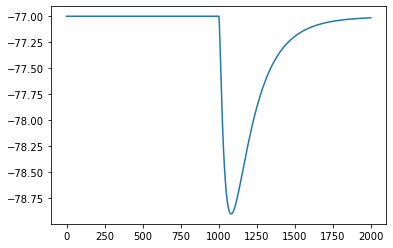

In [16]:
recv0 = EPSP(0.1,3e-3, passive = True, E = False, loc=58, location ='dend')